# Hybrid Quantum-Classical Reinforcement Learning (3/3)

___
___

## Introduction
___


In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- [Part I: Classical vs Qubit agents on the Cart Pole environment](QRL_experiment_1.ipynb)
- [Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments](QRL_experiment_2.ipynb)
- **Part III: Photonic agents on the three environments**

This third notebook will present:
1. Photonic-based PPO
2. Results on Cart Pole
3. Results on Lunar Lander
4. Results on Maze
5. Conclusion

In [1]:
# Uncomment the following line to install dependencies if needed
# !pip install ipynb setuptools==77.0.3 torch torchvision gymnasium swig "gymnasium[box2d]" matplotlib  autoray==0.7.2 scipy==1.13.0 pennylane==0.29.1 StrawberryFields==0.23.0 PennyLane-SF==0.29.1

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import pennylane as qp
from MazeEnvironment import Maze

from ipynb.fs.defs.QRL_experiment_1 import AutoEncoder, PPO, CriticNN, MemoryTracker, load_weights, load_results, plot_results
from ipynb.fs.defs.QRL_experiment_2 import ConvolutionalAE, MazePPO, CriticCNN

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Code works on CPU and GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

# The results are saved in qrl_results/qrl_results.json
results_folder = "qrl_results"
os.makedirs(results_folder, exist_ok=True)
results_filename = "qrl_results.json"

## 1 - Photonic-based PPO
___

The photonic version of PPO uses a continuous-variable (CV) quantum circuit, where information is encoded in the quantum states of optical modes rather than qubits. The photonic quantum circuit used in the article is composed of squeezing, displacement, rotation, and Kerr gates.

<div align="center">
<img src="images/qrl_demo_cvqnn.png" width="500"/>
</div>

The Kerr gate introduces the non-linearity required by the circuit. To run this implementation, we use the Strawberry Fields backend with a deprecated version of PennyLane that still supports the Kerr gate.

In [3]:
class ActorPhotonicNN(nn.Module):
    def __init__(self, input_shape, intermediate_dim, output_dim, device):
        super().__init__()
        self.device = device
        input_dim = input_shape
        n_modes = input_shape//2
        n_layers = intermediate_dim

        shapes = qp.CVNeuralNetLayers.shape(n_layers=n_layers, n_wires=n_modes)
        weight_shapes = {
            name: shape for name, shape in zip(
                ["theta_1", "phi_1", "varphi_1", "r", "phi_r",
                 "theta_2", "phi_2", "varphi_2", "a", "phi_a", "k"],
                shapes,
            )
        }
        
        dev = qp.device("strawberryfields.fock", wires=n_modes, cutoff_dim=10)

        @qp.qnode(dev, interface="torch")
        def qnode(inputs, **weights):
            qp.Squeezing(1/2, np.pi/2, wires=range(n_modes))
            qp.templates.embeddings.DisplacementEmbedding(inputs, wires=range(n_modes))
            qp.CVNeuralNetLayers(*weights.values(), wires=range(n_modes))
            return [qp.expval(qp.X(i)) for i in range(n_modes)]

        self.layer1 = nn.Linear(input_dim, n_modes).to(self.device)
        self.qlayer1 = qp.qnn.TorchLayer(qnode, weight_shapes)
        self.layer2 = nn.Linear(n_modes, output_dim).to(self.device)

    def forward(self, x):
        x = self.layer1(x)
        x = self.qlayer1(x.cpu()).to(self.device)
        x = self.layer2(x)
        return x

## 2 - Results on Cart Pole

In [4]:
# Create the environment
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)
env_name = "Cart Pole"

# Create the config
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 2,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 10000
    }
cp_config["actor_intermediate_dim"] = 1
mode = "photonic"
train = False # ~ 45 min if True

# Launch training
with MemoryTracker() as cp_photonic_stats:
    cp_photonic_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticNN, 
        env=cartpole_env,
        env_name=env_name,
        env_config=cp_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=cp_photonic_stats
        )

    if train:
        qrl_results = cp_photonic_ppo.run()
    else:
       load_weights(results_folder, cp_photonic_ppo, env_name, mode)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading models' weights


RuntimeError: Error(s) in loading state_dict for AutoEncoder:
	size mismatch for encoder.layer3.weight: copying a param with shape torch.Size([1, 32]) from checkpoint, the shape in current model is torch.Size([2, 32]).
	size mismatch for encoder.layer3.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([2]).
	size mismatch for decoder.layer1.weight: copying a param with shape torch.Size([32, 1]) from checkpoint, the shape in current model is torch.Size([32, 2]).

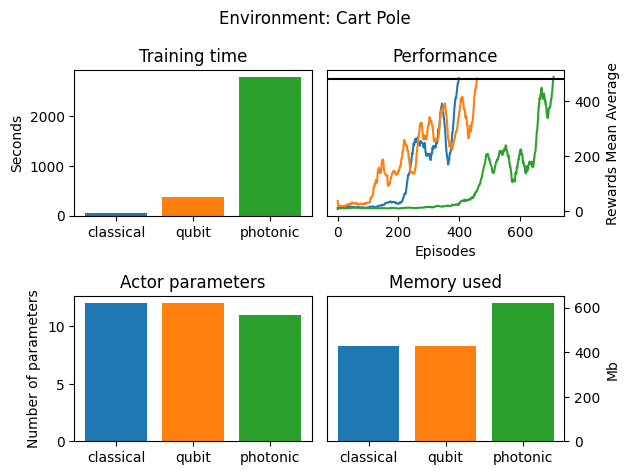

In [ ]:
plot_results(env_name, qrl_results.get(env_name, {}), cp_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 3 - Results on Lunar Lander

In [ ]:
# Create the environment
lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)
env_name = "Lunar Lander"

# Create the config
ll_config = {
    "ae_hidden_dim": 64, "ae_output_dim": 3,
    "critic_intermediate_dim": 128,
    "minibatch_size": 64, "lr": 3e-4,
    "K": 4, "episode_update_frequency": 1, "mean_reward_lookback": 50, "mean_reward_stop": 220,
    "gamma": 0.99, "lambda": 0.98, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 100000
    }
ll_config["actor_intermediate_dim"] = 2
mode = "photonic"
train = False # ~ 3 days if True

# Launch training
with MemoryTracker() as ll_photonic_stats:
    ll_photonic_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticNN, 
        env=lunarlander_env,
        env_name=env_name,
        env_config=ll_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=ll_photonic_stats
        )

    if train:
        qrl_results = ll_photonic_ppo.run()
    else:
       load_weights(results_folder, ll_photonic_ppo, env_name, mode)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading models' weights


RuntimeError: Error(s) in loading state_dict for AutoEncoder:
	size mismatch for encoder.layer3.weight: copying a param with shape torch.Size([2, 64]) from checkpoint, the shape in current model is torch.Size([3, 64]).
	size mismatch for encoder.layer3.bias: copying a param with shape torch.Size([2]) from checkpoint, the shape in current model is torch.Size([3]).
	size mismatch for decoder.layer1.weight: copying a param with shape torch.Size([64, 2]) from checkpoint, the shape in current model is torch.Size([64, 3]).

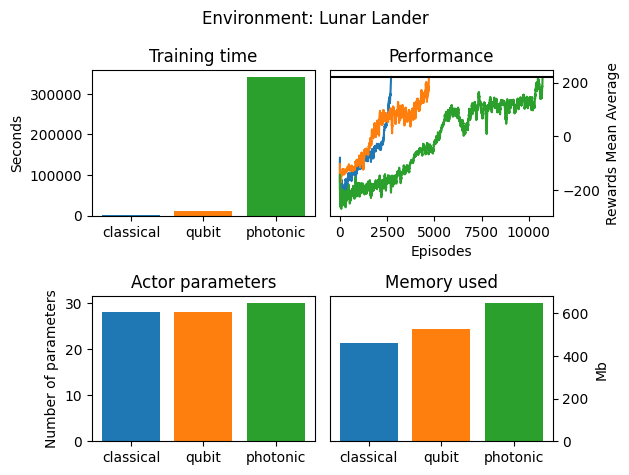

In [ ]:
plot_results(env_name, qrl_results.get(env_name, {}), ll_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 4 - Results on Maze

In [ ]:
# Create the environment
maze_env = Maze()
maze_env.reset(seed=seed)
maze_env.action_space.seed(seed)
maze_env.observation_space.seed(seed)
env_name = "Maze"

# Create the config
m_config = {
    "image_size": 64,
    "ae_hidden_dim": 128, "ae_output_dim": 16, 
    "ae_pretrain_epochs": 200000, "ae_pretrain_n_examples": 100000, "ae_pretrain_batchsize": 128,
    "critic_intermediate_dim": 128,
    "minibatch_size": 128, "lr": 1e-4,
    "K": 8, "episode_update_frequency": 20, "mean_reward_lookback": 30, "mean_reward_stop": 0.9,
    "curriculum_levels": [
        (0, 0, 0, 1), # Level 1
        (0, 0, 0, 3), # Level 2
        (0, 0, 0, 5), # Level 3
        (1, 1, 4, 3), # Level 4
        (1, 1, 4, 5), # Level 5
        (2, 2, 8, 3), # Level 6
        (2, 2, 8, 5), # Level 7
        (3, 3, 8, 3), # Level 8
        (3, 3, 8, 5), # Level 9
        None],        # Level 10
    "gamma": 0.99, "lambda": 0.95, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 1000000
    }
custom_obs_shape = (m_config["image_size"], m_config["image_size"], 3)
m_config["actor_intermediate_dim"] = 1
mode = "photonic"
train = True # ~ 6 days if True
train_ae = False # ~ 12 hours if True

# Launch training
with MemoryTracker() as m_photonic_stats:
    m_photonic_ppo = MazePPO(
        AutoEncoderClass=ConvolutionalAE, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticCNN, 
        env=maze_env,
        env_name=env_name,
        env_config=m_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=m_photonic_stats,
        custom_obs_shape=custom_obs_shape,
        train_ae = train_ae
        )

    if train:
        qrl_results = m_photonic_ppo.run()
    else:
       load_weights(results_folder, m_photonic_ppo, env_name, mode)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading ConvolutionalAE weights
340

Loading models' weights
Weights for ae do not exist !
Weights for actor do not exist !
Weights for critic do not exist !


Results for classical (Maze) don't exist !
Results for qubit (Maze) don't exist !
Results for photonic (Maze) don't exist !


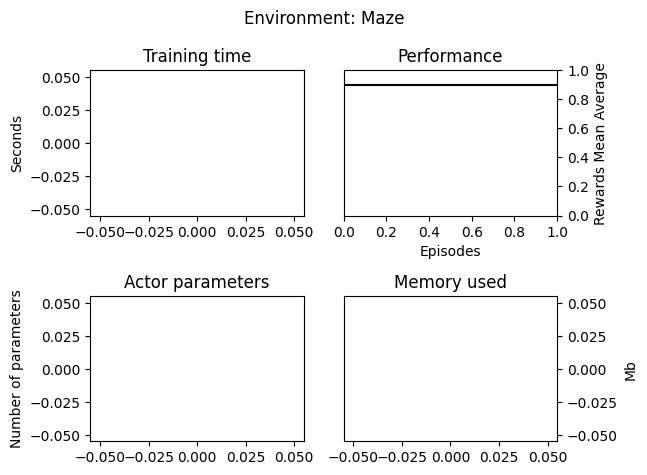

In [16]:
plot_results(env_name, qrl_results.get(env_name, {}), m_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 5 - Conclusion
___

It takes a lot less photonic qumodes and layers to reach the same amount of parameters. Training time is the biggest limitation here though, with the simulation taking much longer than the classical and qubit-based methods.

In the article, the authors used an alternative to the no-longer maintained Strawberry-Fields photonic library: [Piquasso](https://github.com/Budapest-Quantum-Computing-Group/piquasso). You can find more information about it in this article: ["Piquasso: A Photonic Quantum Computer Simulation Software Platform"](https://arxiv.org/pdf/2403.04006)